<a href="https://colab.research.google.com/github/SalmaLilad/UCSC-PYaR-Research/blob/main/programs/5-Simulated%20Disk%20Activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this activity, you are going to simulate the disk of Andromeda!

Begin, as before, by importing the key programs. "fakedisk" is the program that will generate the simulated disk--matplotlib and numpy should be familar to you at this point.

In [ ]:
# This clones your repo and sets the directory so the notebooks can find the 'data' folder
import os

repo_url = "https://github.com/SalmaLilad/UCSC-PYaR-Research"
repo_name = "UCSC-PYaR-Research"

if not os.path.exists(repo_name):
    !git clone {repo_url}

# Move the working directory into the 'programs' folder so file paths like '../data/' work
os.chdir(f"{repo_name}/programs")

print(f"Current working directory: {os.getcwd()}")

In [1]:
from fakedisk import fakedisk
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

The following routine makes a plot of the simulated disk. Run this cell.

In [26]:
def show_map(sim, quantity, label, vmin=-200, vmax=200, cutout=False):
    ax = plt.axes(aspect = 'equal')

    ax.set_xlabel('xi (kpc)')
    ax.set_ylabel('eta (kpc)')
    ax.set_title('Simulation')
    ax.set_xlim(1.2 * max(sim.x), 1.2 * min(sim.x))

    if cutout:
        #clip into "mystery cutout"
        sideL  = 0.25 * sim.scaleFactor
        ax.set_xlim(sideL, -sideL)
        ax.set_ylim(-sideL, sideL)

    tt = ax.scatter(sim.x, sim.z, c=quantity, edgecolors='none', s=2, vmin=vmin, vmax=vmax, cmap='cool')

    plt.colorbar(tt, label = label)

Now, we'd like to create our fake disk! This occurs below when the program "fakedisk" is called.

In [32]:
scale_factor = 20. #Scale length of the disk
dispersion = 1000.    #Dispersion in the layer
incl=77. #Inclination
pa0=30.7 #Position Angle
vrot=206.
n=1000
sim = fakedisk(N=n, incl=incl, pa0=pa0, v=vrot, scaleFactor=scale_factor, shape='constant',
               dispersion=dispersion)

Generate plots of your simulated velocity field below.

Once you've made these plots, go back and change the following parameters to see what they mean. What happens when you change the scale factor? The dispersion? The inclination? The position angle? N? Can you guess what these different parameters are referring to?

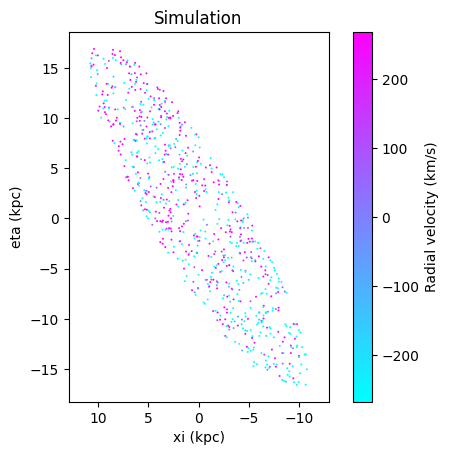

In [35]:
#Generate velocity map
vmax = 1.3 * sim.vrot
show_map(sim, sim.vy, 'Radial velocity (km/s)', vmin=-vmax, vmax=vmax)

c:\Users\saanv\Downloads\UCSC-PYaR-Research-main\UCSC-PYaR-Research\programs\fakedisk.py:132: RuntimeWarning: divide by zero encountered in scalar divide
  I11 = np.sum(1/sv**2)
c:\Users\saanv\Downloads\UCSC-PYaR-Research-main\UCSC-PYaR-Research\programs\fakedisk.py:133: RuntimeWarning: invalid value encountered in divide
  I22 = I11 + np.sum(3 * (v - mu)**2/sv**4+ 2/sv**2)
c:\Users\saanv\Downloads\UCSC-PYaR-Research-main\UCSC-PYaR-Research\programs\fakedisk.py:133: RuntimeWarning: divide by zero encountered in scalar divide
  I22 = I11 + np.sum(3 * (v - mu)**2/sv**4+ 2/sv**2)
c:\Users\saanv\Downloads\UCSC-PYaR-Research-main\UCSC-PYaR-Research\programs\fakedisk.py:134: RuntimeWarning: invalid value encountered in divide
  I12 = np.sum(2 * (v - mu)/sv**3)


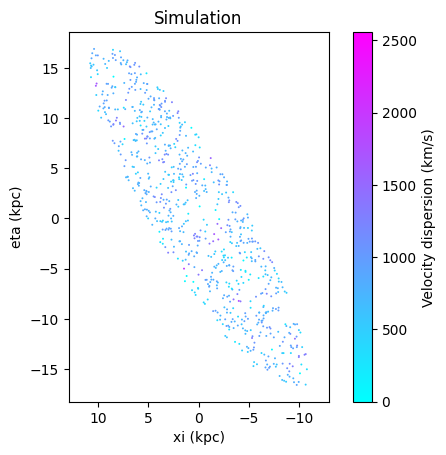

In [36]:
#Generate dispersion map using 200'' smoothing circle.
arcsec2kpc = (13.67/3600.) #conversion factor
sigma = np.zeros(len(sim.x))
sig_sv = np.zeros(len(sim.x))
smoothingCircle = 200. * arcsec2kpc
for i in range(len(sigma)):
    sigma[i], sig_sv[i] = sim.get_sv(i, smoothingCircle)
show_map(sim, sigma, 'Velocity dispersion (km/s)', vmin=0, vmax=1.3*np.max(sigma))

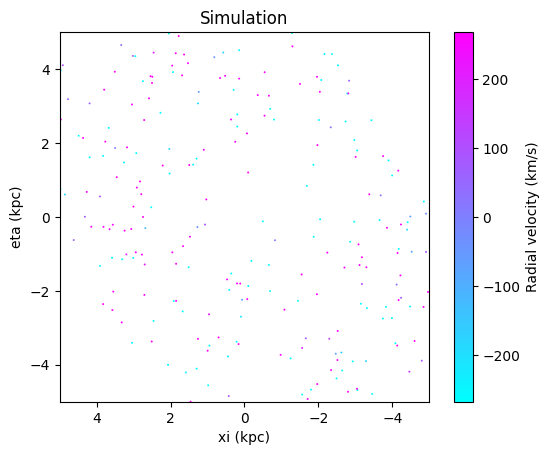

In [37]:
#Also generate a little square cutout velocity map.
vmax = 1.3 * sim.vrot
show_map(sim, sim.vy, 'Radial velocity (km/s)', vmin=-vmax, vmax=vmax, cutout=True)

Now that you're familiar with the parameters and the figures, change the parameters for fakedisk to answer the following questions (feel free to double click on this cell and type your answers below the questions):

1) If galaxies A and B have the same geometry, but galaxy A has twice the rotation speed of galaxy B, how do the velocity fields differ on the major axis? On the minor axis? In between?

The velociites will be 2x as large at every point across the major axis, zero radial velocity along the minor axis and will be steeper in between.

2) If galaxies C and D have the same PA and rotation speed, but galaxy C has an inclination half that of D, how do the velocity fields differ?

D will show generally lower observed velocities.

3) If galaxies E and F have the same inclination and rotation speed, but galaxy E’s major axis position angle is the negative of galaxy F’s, how do the velocity fields differ?

The velocities will be mirror images of each other.

What PA, inclination, velocity, and/or disk radius would make it easiest to study the properties of a real galaxy? What parameters most closely reproduce M31‘s velocity map that you made last time?

In [ ]:
#Easiest to study a real galaxy
incl=46
pa0=64
v=245
d_r=25

#Reproduce MRI's velocity map
incl=77
pa0=36.5
v=225
d_r=45